<a href="https://colab.research.google.com/github/alyplasc/climate-modeling-f26--ap4825-/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
### Load modules/functions ###
import os
import numpy as np
import xarray as xr

from matplotlib import pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches

from IPython.display import Image
from matplotlib import image


%config InlineBackend.figure_format = 'retina'
%matplotlib inline

# where you want the SST data file to go
dest = './ERSSTv5.sst.mnmean.nc'
url  = 'https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/sst.mnmean.nc'

# large data, so we check if it has been downloaded
if os.path.exists(dest):
    !curl -L -R -z "{dest}" -o "{dest}" --fail "{url}"  ## only download if the remote file is newer...
else:
    !curl -L -R -o "{dest}" --fail "{url}"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:10 --:--:--     0


In [72]:
dest = './ERSSTv5.sst.mnmean.nc'
ds_ersstv5 = xr.open_dataset(dest)
### Check data
ds_ersstv5

## Name the variables using conventional name
ds_ersstv5 = ds_ersstv5.rename({'lat': 'latitude', 'lon': 'longitude'})
ds_ersstv5.attrs['short_name'] = 'ERSSTv5'
ds_ersstv5

<xarray.Dataset> Size: 133MB
Dimensions:    (time: 2072, nbnds: 2, latitude: 89, longitude: 180)
Coordinates:
  * time       (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-08-01
  * latitude   (latitude) float32 356B 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * longitude  (longitude) float32 720B 0.0 2.0 4.0 6.0 ... 354.0 356.0 358.0
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB ...
    sst        (time, latitude, longitude) float32 133MB ...
Attributes: (12/38)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2026-09-03
    short_name:                ERSSTv5

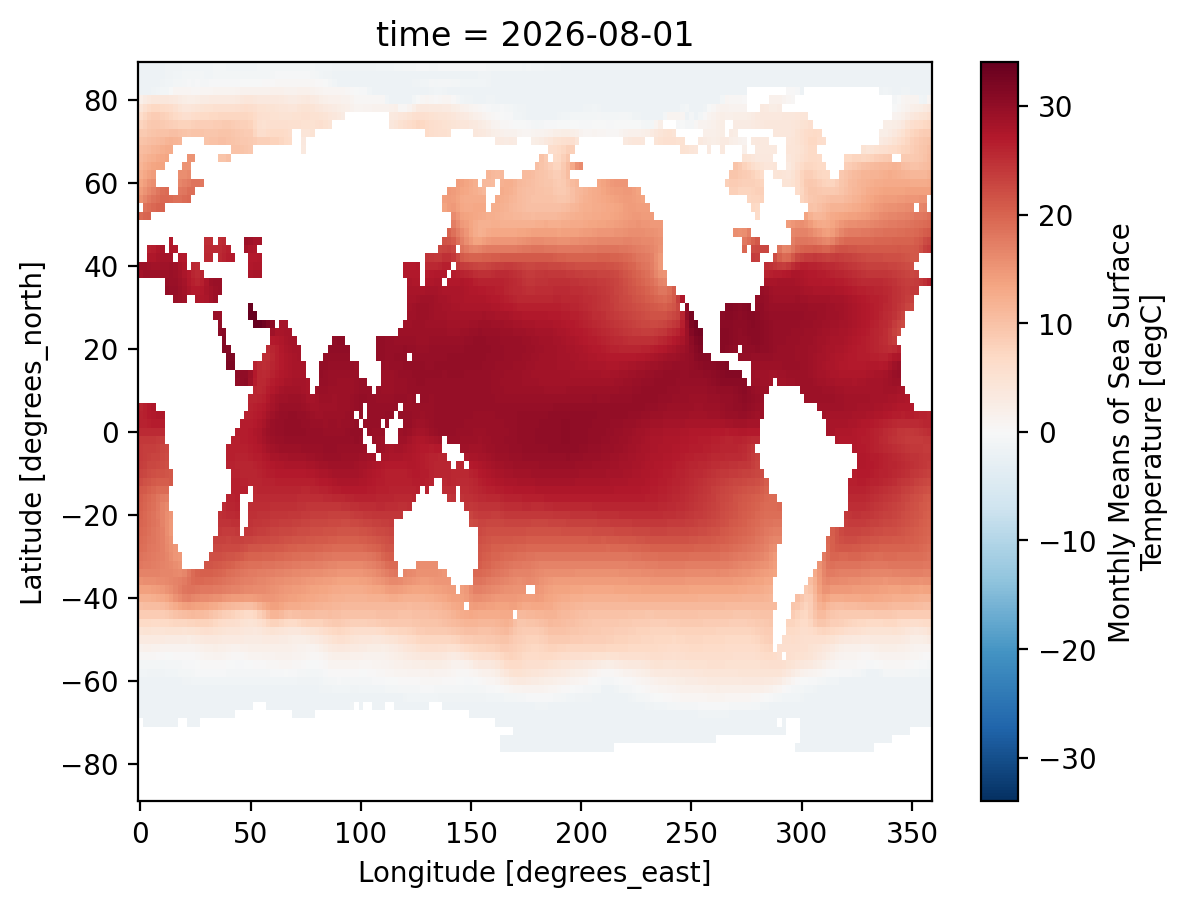

In [73]:
### 2D map of SST for July
sst = ds_ersstv5['sst']
#sst.isel(time=-1).plot()
sst.sel(time='2026-08-01').plot()
plt.savefig('August_SST.png',dpi=200)
plt.show()


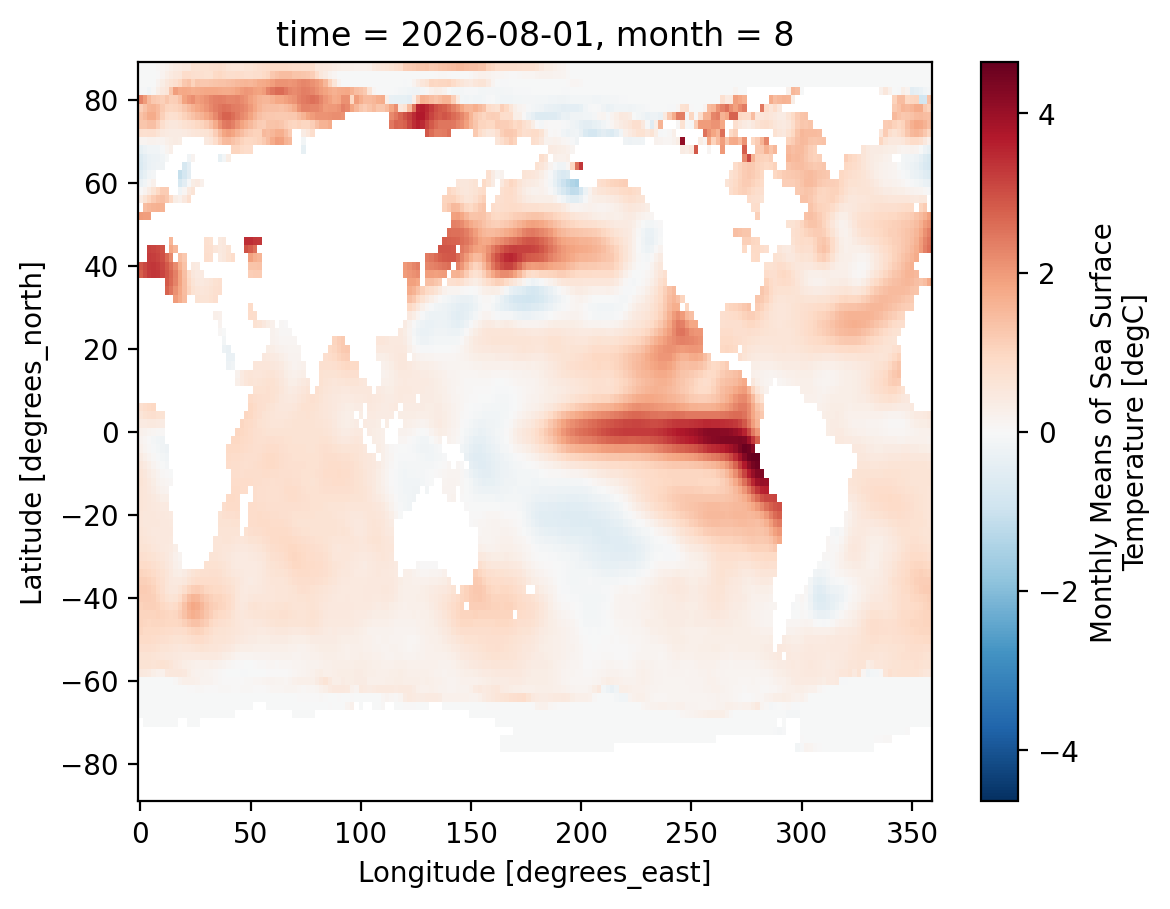

In [74]:
### NOAA's definition of climatology -- past 30 years
monthly_mean_sst = sst.sel(time=slice('1991', '2020')).groupby('time.month').mean('time')
ssta = sst.groupby('time.month') - monthly_mean_sst
ssta.isel(time=-1).plot()

In [75]:
def n34_average(x):
    """
    Calculate x (temperature) over Niño 3.4 region"
    Note that grid cells near the equator represent more actual surface area than cells near the poles
    (since longitude lines converge toward the poles),
    so a simple unweighted mean would bias the average toward high latitudes. Weighting by cos(latitude) corrects for this.
    """

    x = x.sortby("latitude")
    weights = np.cos(np.deg2rad(x.latitude))
    y = x.sel(longitude=slice(190, 240)).sel(latitude=slice(-5, 5)).weighted(weights).mean(['longitude', 'latitude'])
    y.attrs = x.attrs.copy()
    return y


HW Question 5:

In [76]:
n34 = n34_average(ssta) # Corrected to use ssta (SST anomaly) instead of raw sst

# Time slice for 1991-2020
n34a = n34.sel(time=slice('1991', '2020'))

# Calculate and print statistics
mean_val = np.mean(n34a)
std_dev_val = np.std(n34a)
skew_val = stats.skew(n34a)
kurt_val = stats.kurtosis(n34a)

print(f"Niño 3.4 Anomaly (1991-2020) Statistics:")
print(f"Sample Mean:           {mean_val:.4f}")
print(f"Standard Deviation:    {std_dev_val:.4f}")
print(f"Skewness:              {skew_val:.4f}")
print(f"Kurtosis:              {kurt_val:.4f}")

Niño 3.4 Anomaly (1991-2020) Statistics:
Sample Mean:           -0.0000
Standard Deviation:    0.8757
Skewness:              0.4989
Kurtosis:              0.4015


HW Question #6:

In [77]:
# Calculate the percentiles
percentiles = np.quantile(n34a, [0.05, 0.25, 0.50, 0.75, 0.95])

# Print the results
print("Niño 3.4 Anomaly Percentiles (1991-2020):")
print(f"5th percentile:  {percentiles[0]:.4f}")
print(f"25th percentile: {percentiles[1]:.4f}")
print(f"50th percentile: {percentiles[2]:.4f}")
print(f"75th percentile: {percentiles[3]:.4f}")
print(f"95th percentile: {percentiles[4]:.4f}")

Niño 3.4 Anomaly Percentiles (1991-2020):
5th percentile:  -1.3908
25th percentile: -0.5976
50th percentile: -0.0359
75th percentile: 0.4857
95th percentile: 1.6235


HW Question 7: Given then the standard deviation is close to 1, this means the anomoly data resembles a normal distribution. However, the skewness is slightly positive meaning that the data is right skewed and slightly asymmetrical.  

In [78]:
df = pd.read_csv('/content/hurricane_counts_by_enso.csv')


In [79]:
import pandas as pd
from scipy import stats

# Separate hurricane counts for El Niño and La Niña
el_nino_counts = df[df['enso_phase'] == 'El Nino']['hurricane_count']
la_nina_counts = df[df['enso_phase'] == 'La Nina']['hurricane_count']

# Perform independent t-test to compare means
t_stat, p_value_ttest = stats.ttest_ind(el_nino_counts, la_nina_counts, equal_var=False) # Welch's t-test assuming unequal variances

alpha = 0.05

print("### Statistical Analysis of North Atlantic TC Counts (El Niño vs. La Niña) ###")
print(f"Significance Level (α): {alpha}")
print("\n--- T-test for Means ---")
print(f"El Niño Mean TC Count: {el_nino_counts.mean():.2f}")
print(f"La Niña Mean TC Count: {la_nina_counts.mean():.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value (t-test): {p_value_ttest:.3f}")


### Statistical Analysis of North Atlantic TC Counts (El Niño vs. La Niña) ###
Significance Level (α): 0.05

--- T-test for Means ---
El Niño Mean TC Count: 10.19
La Niña Mean TC Count: 15.14
T-statistic: -3.430
P-value (t-test): 0.002


HW Question #8: Based on the extremely small p-value, we reject the null hypothesis. There is a statistically significant difference in the average TCs during El Nino versus El Nina.

In [80]:
## for f-test
def f_test(x1, x2):
    f_stat = x2.var(ddof=1) / x1.var(ddof=1)
    dfn, dfd = len(x2) - 1, len(x1) - 1
    p_f = 2 * min(stats.f.cdf(f_stat, dfn, dfd), 1 - stats.f.cdf(f_stat, dfn, dfd))
    return f_stat,dfn,dfd,p_f

In [81]:
f_stat,dfn,dfd,p_f = f_test(el_nino_counts,la_nina_counts)
print(f"F-test: F={f_stat:.4f}, df1={dfn}, df2={dfd}, p={p_f:.4f}")

F-test: F=1.9074, df1=20, df2=20, p=0.1574


HW Question #9:


Since the p-value is above 0.05, we fail to reject the null hypothesis. This means we found no statistically significant difference in the variance between the number of tropical cyclones during el Nino versus la Nina.

HW Question #10:

In [82]:
kw_stat, kw_pval = stats.kruskal(el_nino_counts, neutral_counts, la_nina_counts)
print("\n--- Question 10: Kruskal-Wallis test ---")
print(f"H-statistic: {kw_stat:.4f}")
print(f"p-value:     {kw_pval:.4e}")


--- Question 10: Kruskal-Wallis test ---
H-statistic: 14.3211
p-value:     7.7662e-04


Based on the p-value, we reject the null hypothesis that there is no difference in the distribution in the counts of hurricanes between el nino, neutral and la nina.